Sequence shapes: X_seq: (44240, 56, 7), y_seq: (44240, 1)
Data split: Train: (35392, 56, 7), Test: (8848, 56, 7)

 Training lstm model...
Epoch 1/2
443/443 [==============================] - 10s 15ms/step - loss: 0.1630 - val_loss: 0.1841
Epoch 2/2
277/277 [==============================] - 3s 8ms/step
 Evaluating lstm model...
277/277 [==============================] - 2s 8ms/step
lstm Test MSE: 4092231.4859
lstm Test MAE: 1301.3432
lstm Test nRMSE: 0.0966
lstm Test nMAE: 0.0622


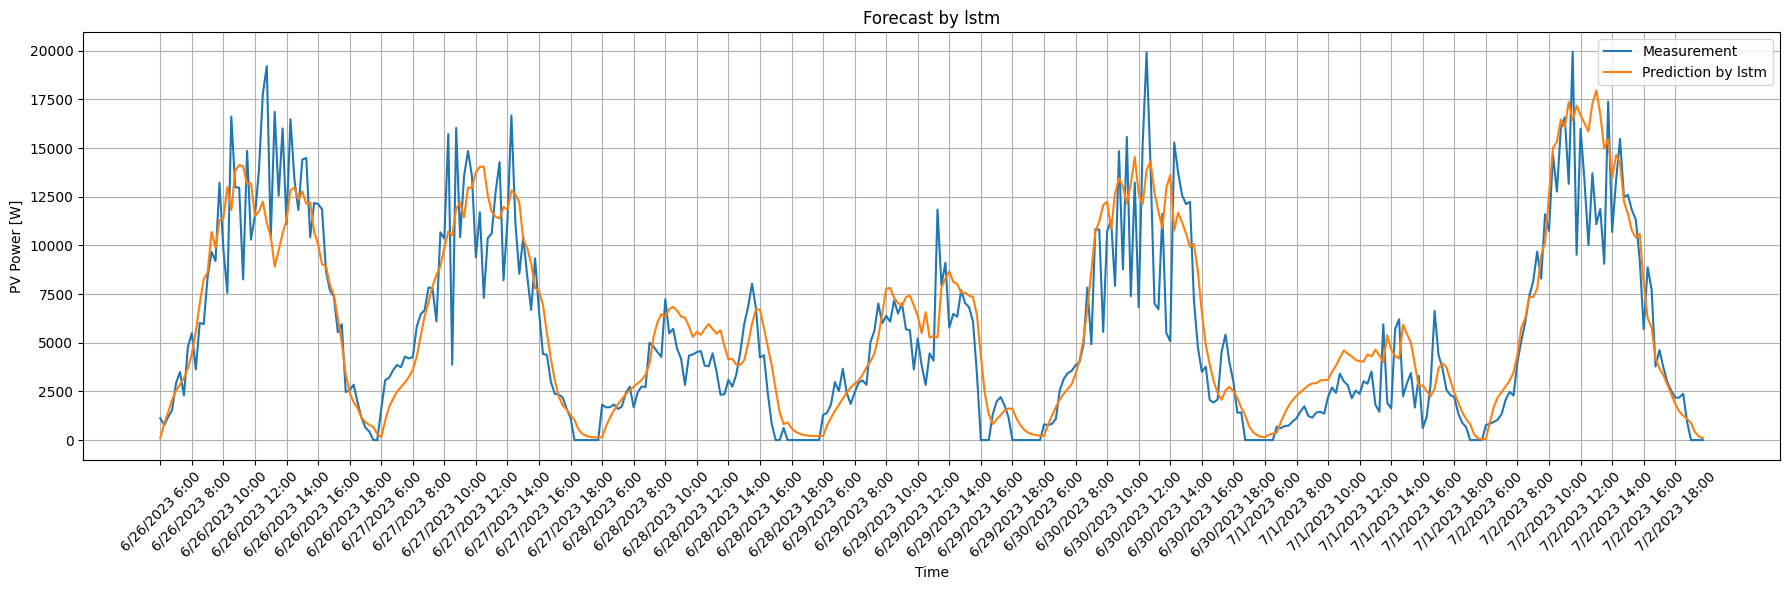

(0.09661507621388693, 0.06215222004386399)

In [ ]:
from solar_fork import SeqDataset
from solar_fork import ForecastModel
from solar_fork import evaluate_and_plot


# Initialize dataset
dataset = SeqDataset('./solar_fork/data/data_UT_clean.csv', seq_length=56)
# Initialize forecaster (available models: "lstm", "gru", "cnn", "tcn", "transformer", "ann")
forecaster = ForecastModel(name="lstm", seq_length=dataset.seq_length, input_dim=dataset.X_train.shape[-1])
# Train the model
forecaster.train(dataset.X_train, dataset.y_train, epochs=2, batch_size=64)
forecaster.predict(dataset.X_test)

evaluate_and_plot(forecaster, dataset)